# Predicting Falcon 9 first-stage landing success

## Machine-learning models for landing prediction

A reusable first stage is central to the Falcon 9's low launch cost, so predicting whether the stage will land has real operational value. This notebook trains and compares four classifiers on the engineered features and reports their performance.

### Objectives

- Load the labelled data and engineered features
- Split into train and test sets and standardise the features
- Train logistic regression, SVM, decision tree and KNN with grid search
- Compare the models with several metrics

In [1]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn

Import the modelling libraries and fix the random seed for reproducibility.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 2
np.random.seed(RANDOM_STATE)


A helper to plot a confusion matrix.

In [3]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the data

Load the labelled table and the engineered feature matrix.

In [4]:
data = pd.read_csv("../data/processed/dataset_part_2.csv")


In [5]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [6]:
X = pd.read_csv('../data/processed/dataset_part_3.csv')


In [7]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


### The target vector

Create the target vector `Y` from the `Class` column.

In [8]:
Y = pd.Series(data['Class'].to_numpy())
Y.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    1
7    1
8    0
9    0
dtype: int64

### Feature scaling

Standardise the features. *(Fix: the scaler is now fitted on the training split only, instead of on the full dataset, which leaked test information into training.)*

In [9]:
# Standardisation is applied after the train/test split below,
# so the scaler is fitted on the training data only.
transform = preprocessing.StandardScaler()


*Fix: the train/test split is now stratified, so both sets preserve the class balance.*

### Train/test split

Split the data with `test_size=0.2` and `random_state=2`, stratifying on `Y`; then fit the scaler on the training data and apply it to both parts.

The resulting variables are `X_train, X_test, Y_train, Y_test`.

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE, stratify=Y)

# Fit the scaler on the training split only, then transform both parts.
X_train = transform.fit_transform(X_train)
X_test = transform.transform(X_test)


The test set has 18 launches.

In [11]:
Y_test.shape

(18,)

### Logistic regression

Train a logistic-regression classifier with a small grid search over `C` (10-fold cross-validation).

In [12]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [13]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

Report the best parameters and the cross-validated accuracy.

In [14]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.85


### Logistic regression test accuracy

Compute accuracy on the held-out test set.

In [15]:
logreg_accuracy = logreg_cv.score(X_test, Y_test) 
print("Test Accuracy:", logreg_accuracy)

Test Accuracy: 0.8333333333333334


Confusion matrix for logistic regression.

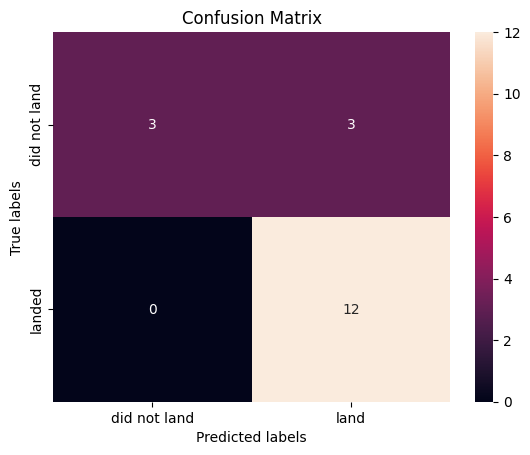

In [16]:
logreg_yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,logreg_yhat)

Logistic regression separates the classes without false negatives here; the errors are false positives — launches predicted to land that in fact did not.

### Support vector machine

Train an SVM with a grid search over kernel, `C` and `gamma`.

In [17]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [18]:
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid')})

In [19]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8642857142857144


### SVM test accuracy

Compute the SVM's test accuracy.

In [20]:
svm_accuracy = svm_cv.score(X_test, Y_test) 
print("Test Accuracy:", svm_accuracy)

Test Accuracy: 0.8333333333333334


SVM confusion matrix.

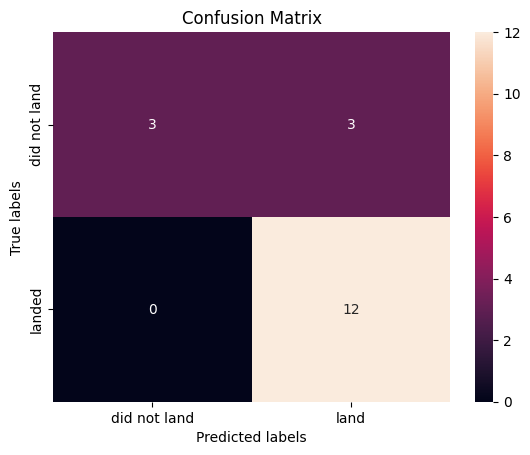

In [21]:
svm_yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,svm_yhat)

### Decision tree

Train a decision-tree classifier with a grid search over depth, split criterion and leaf settings.

In [22]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['sqrt', 'log2'], # removed 'auto'
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [23]:
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [24]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 18, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
accuracy : 0.9428571428571428


### Decision tree test accuracy

Compute the decision tree's test accuracy.

In [25]:
tree_accuracy = tree_cv.score(X_test, Y_test) 
print("Test Accuracy:", tree_accuracy)

Test Accuracy: 0.6666666666666666


Decision tree confusion matrix.

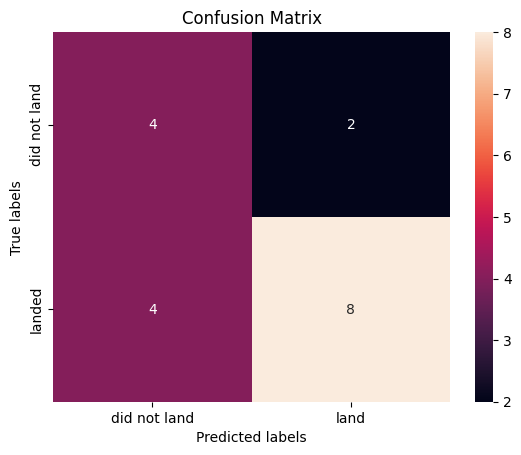

In [26]:
tree_yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,tree_yhat)

### K nearest neighbours

Train a KNN classifier with a grid search over the number of neighbours and the distance metric.

In [27]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [28]:
# Create the GridSearchCV object with cv=10 
knn_cv = GridSearchCV(KNN, parameters, cv=10) 
# Fit the object on your training data 
knn_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [29]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 4, 'p': 1}
accuracy : 0.8642857142857142


### KNN test accuracy

Compute the KNN test accuracy.

In [30]:
knn_accuracy = knn_cv.score(X_test, Y_test) 
print("Test Accuracy:", knn_accuracy)

Test Accuracy: 0.7777777777777778


KNN confusion matrix.

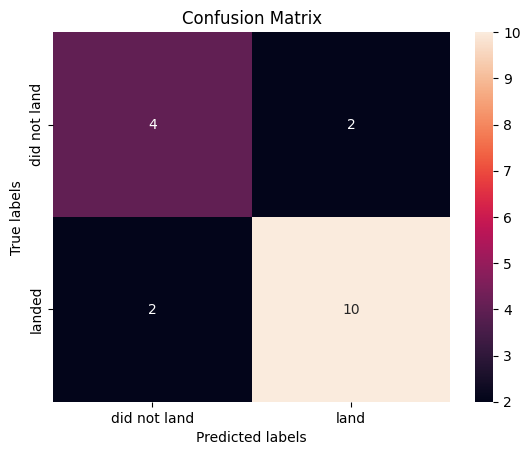

In [31]:
knn_yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,knn_yhat)

### Comparing the models

Assemble Jaccard, F1, precision, recall, accuracy and AUC into one comparison table. *(Fix: AUC is computed from decision scores / predicted probabilities rather than hard 0/1 labels.)*

In [32]:
from sklearn.metrics import jaccard_score, f1_score, precision_score, roc_curve, roc_auc_score, recall_score

# Examining the scores from Test sets
jaccard_scores = [
                  jaccard_score(Y_test, logreg_yhat, average='binary'),
                  jaccard_score(Y_test, svm_yhat, average='binary'),
                  jaccard_score(Y_test, tree_yhat, average='binary'),
                  jaccard_score(Y_test, knn_yhat, average='binary'),
                 ]

f1_scores = [
             f1_score(Y_test, logreg_yhat, average='binary'),
             f1_score(Y_test, svm_yhat, average='binary'),
             f1_score(Y_test, tree_yhat, average='binary'),
             f1_score(Y_test, knn_yhat, average='binary'),
            ]

precision_scores = [
                    precision_score(Y_test, logreg_yhat, average='binary'),
                    precision_score(Y_test, svm_yhat, average='binary'),
                    precision_score(Y_test, tree_yhat, average='binary'),
                    precision_score(Y_test, knn_yhat, average='binary'),
                   ]
recall_scores = [
                 recall_score(Y_test, logreg_yhat, average='binary'),
                 recall_score(Y_test, svm_yhat, average='binary'),
                 recall_score(Y_test, tree_yhat, average='binary'),
                 recall_score(Y_test, knn_yhat, average='binary'),
                ]

accuracy = [logreg_accuracy, svm_accuracy, tree_accuracy, knn_accuracy]


def _auc_scores(model, features):
    """ROC AUC from ranking scores (probabilities when available)."""
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(features)[:, 1]
    else:
        scores = model.decision_function(features)
    return roc_auc_score(Y_test, scores)


auc = [
       _auc_scores(logreg_cv, X_test),
       _auc_scores(svm_cv, X_test),
       _auc_scores(tree_cv, X_test),
       _auc_scores(knn_cv, X_test)
      ]



# Build DataFrame from a list (not via np.array) so heterogeneous objects (like 2x2 arrays) are allowed
scores = pd.DataFrame(
    [jaccard_scores, f1_scores, precision_scores, recall_scores, accuracy, auc],
    index=['Jaccard_Score', 'F1_Score', 'Precision_Score', 'Recall_Score', 'Accuracy', 'AUC'],
    columns=['LogReg', 'SVM', 'Tree', 'KNN']
)
scores


,LogReg,SVM,Tree,KNN
Jaccard_Score,0.800000,0.800000,0.571429,0.714286
F1_Score,0.888889,0.888889,0.727273,0.833333
Precision_Score,0.800000,0.800000,0.800000,0.833333
Recall_Score,1.000000,1.000000,0.666667,0.833333
Accuracy,0.833333,0.833333,0.666667,0.777778
AUC,0.694444,0.750000,0.743056,0.715278


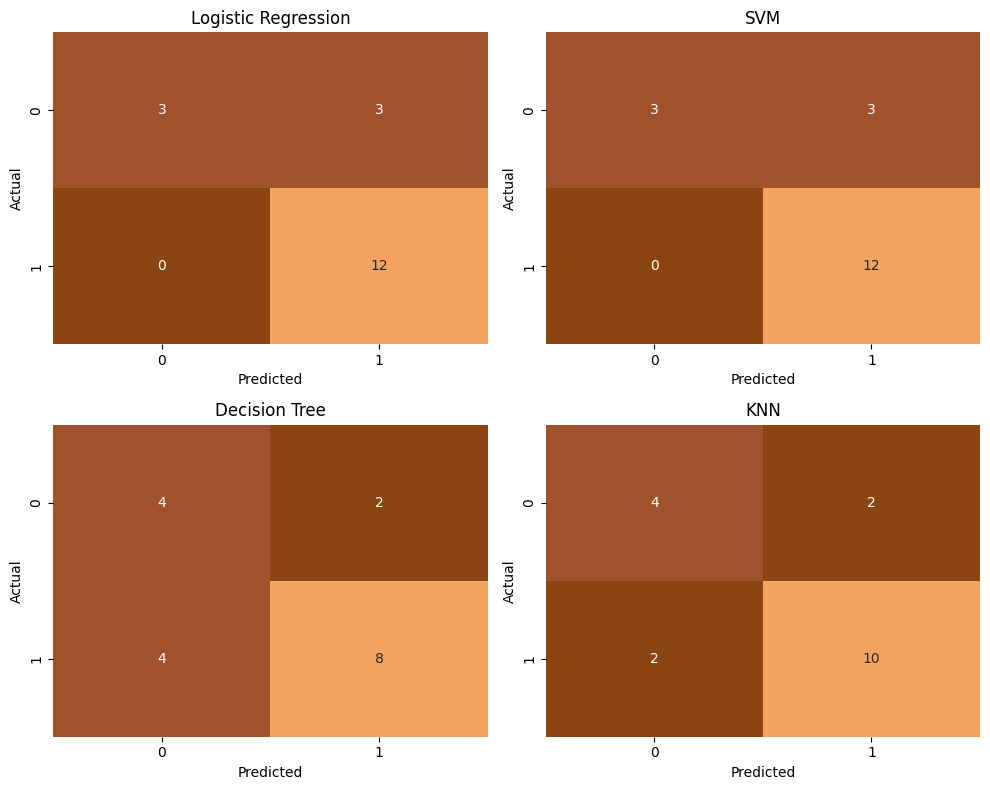

In [33]:

from sklearn.metrics import confusion_matrix


models = ["Logistic Regression", "SVM", "Decision Tree", "KNN"]
y_preds = [logreg_yhat, svm_yhat, tree_yhat, knn_yhat]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
cmap = sns.color_palette(["#8B4513", "#A0522D", "#D2691E", "#F4A460"])

for ax, model, y_pred in zip(axes.flatten(), models, y_preds):
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)
    ax.set_title(model)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Headline result

Because the classes are imbalanced (many more successful landings than failures), accuracy alone is optimistic, so **F1 for the `land` class is the headline metric**, supported by recall and the confusion matrices. On the 18-launch holdout, logistic regression and SVM both reach F1 = 0.889 and accuracy = 0.833, while the tuned decision tree attains the best cross-validated accuracy (0.943) but only 0.667 on the test set — a clear sign of overfitting on this small sample. Exact scores are in the comparison table above and are discussed in `reports/report.md` (with the caveats in `reports/limitations.md`).